# LSTM Vehicle Trajectory Prediction — NGSIM US-101

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from scipy.signal import savgol_filter
OBS  = 30   # 30 frames observed  = 3s at 10Hz
PRED = 10   # 10 frames predicted = 1s at 10Hz

# Pre-Processing

In [ ]:
def smooth_track(group):
    group = group.copy()
    #avoid striding window clash
    if len(group) >= 11:
        group['Local_X'] = savgol_filter(group['Local_X'], window_length=11, polyorder=2)
        group['Local_Y'] = savgol_filter(group['Local_Y'], window_length=11, polyorder=2)
    return group

df = pd.read_csv('data/ngsim_us101.csv')
df = df[df['Location'] == 'us-101']
df = df.groupby('Vehicle_ID').apply(smooth_track).reset_index(drop=True)
# sort and filter to vehicles with enough frames first
min_frames = 100
valid_ids = df.groupby('Vehicle_ID').filter(lambda g: len(g) >= min_frames)['Vehicle_ID'].unique()
valid_ids = np.sort(valid_ids)  # might still be gaps in between vehicles


C:\Users\labib\AppData\Local\Temp\ipykernel_28328\4236148833.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Vehicle_ID').apply(smooth_track).reset_index(drop=True)


In [ ]:
train_ids = valid_ids[:400] #dropped from 1000 data points
val_ids   = valid_ids[400:500] #dropped from 1000:1100
test_ids  = valid_ids[500:600] #Dropped from 1100:1200
train_df  = df[df['Vehicle_ID'].isin(train_ids)]
val_df    = df[df['Vehicle_ID'].isin(val_ids)]
test_df   = df[df['Vehicle_ID'].isin(test_ids)]
print(f'Vehicles  Train:{len(train_ids)}  Val:{len(val_ids)}  Test:{len(test_ids)}')
print(f'Total valid vehicles: {len(valid_ids)}')

Vehicles  Train:1000  Val:100  Test:100
Total valid vehicles: 2847


In [ ]:
# pick one sequence per vehicle from the test set
# we need to track which vehicle each sequence belongs to
# modify make_sequences to also return vehicle IDs

def make_sequences(df):
    X, Y, VIDs = [], [], []
    for vid, track in df.groupby('Vehicle_ID'):
        # Sort by Frame_ID so positions are in chronological order.
        track = track.sort_values('Frame_ID').reset_index(drop=True)
        #is there still any gaps? just give it value of 1 if smalle
        gaps = track['Frame_ID'].diff().fillna(1)
        # if vehicle left the camera view, break track into segments
        break_idx = [0] + list(np.where(gaps > 1)[0]) + [len(track)]
        #process each segments
        for j in range(len(break_idx) - 1):
            
            segments = track.iloc[break_idx[j]:break_idx[j+1]]
            
            segments = segments[['Local_X', 'Local_Y']].values
            if len(segments) < OBS + PRED:
                continue
            for i in range(0, len(segments) - OBS - PRED + 1, 10):
                obs = segments[i : i + OBS].copy()
                fut    = segments[i + OBS : i + OBS + PRED].copy()
                origin = obs[0].copy()
                obs    = obs - origin
                fut    = fut - origin
                X.append(obs)
                Y.append(fut)
                VIDs.append(vid)   # track which vehicle
    return (np.array(X, dtype=np.float32),
            np.array(Y, dtype=np.float32),
            np.array(VIDs))

X_train, Y_train, vids_train = make_sequences(train_df)
X_val,   Y_val,   vids_val   = make_sequences(val_df)
X_test,  Y_test,  vids_test  = make_sequences(test_df)

In [ ]:
# Fit scaler only on training data
sx = StandardScaler().fit(X_train.reshape(-1, 2))
sy = StandardScaler().fit(Y_train.reshape(-1, 2))

def scale(X, Y):
    Xn = sx.transform(X.reshape(-1, 2)).reshape(len(X), OBS,  2).astype(np.float32)
    Yn = sy.transform(Y.reshape(-1, 2)).reshape(len(X), PRED, 2).astype(np.float32)
    return Xn, Yn

# Store raw test data before scaling — needed to anchor predictions
X_test_raw = X_test.copy()

X_train, Y_train = scale(X_train, Y_train)
X_val,   Y_val   = scale(X_val,   Y_val)
X_test,  Y_test  = scale(X_test,  Y_test)
print(f'Scaled  mean:{X_train.mean():.3f}  std:{X_train.std():.3f}')

Scaled  mean:-0.000  std:1.000


# Dataloaders

In [ ]:
class TrajDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X)
        self.Y = torch.tensor(Y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

train_loader = DataLoader(TrajDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TrajDataset(X_val,   Y_val),   batch_size=64)
test_loader  = DataLoader(TrajDataset(X_test,  Y_test),  batch_size=64)

# Long Short Term Mmeory Architecture

In [ ]:
class LSTMTrajectory(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMTrajectory, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.decoder = nn.LSTM(2, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        _, (h, c)  = self.encoder(x, (h, c))
        # last observed frame instead of zeros
        dec_input = x[:, -1:, :] 
        outputs    = []
        for _ in range(PRED):
            out, (h, c) = self.decoder(dec_input, (h, c))
            step = self.fc(out.squeeze(1))
            outputs.append(step.unsqueeze(1))
            dec_input = step.unsqueeze(1)
        return torch.cat(outputs, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = LSTMTrajectory(input_size=2, hidden_size=128, num_layers=2).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

LSTMTrajectory(
  (encoder): LSTM(2, 128, num_layers=2, batch_first=True, dropout=0.3)
  (decoder): LSTM(2, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)
Parameters: 416,130


# Training

In [11]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val  = float('inf')
patience_counter = 0

for epoch in range(1, 80):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss   = criterion(model(xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb    = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item()

    tl = train_loss / len(train_loader)
    vl = val_loss   / len(val_loader)
    scheduler.step(vl)

    if vl < best_val:
        best_val = vl
        patience_counter = 0
        torch.save(model.state_dict(), 'lstm_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= 30:
            print(f'Early stop at epoch {epoch}')
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | Train: {tl:.4f} | Val: {vl:.4f}')

Epoch 010 | Train: 0.5232 | Val: 0.5325
Epoch 020 | Train: 0.5224 | Val: 0.5304
Epoch 030 | Train: 0.5208 | Val: 0.5293
Epoch 040 | Train: 0.5202 | Val: 0.5289
Epoch 050 | Train: 0.5202 | Val: 0.5287
Epoch 060 | Train: 0.5196 | Val: 0.5285


KeyboardInterrupt: 

# Test Results Visualisation

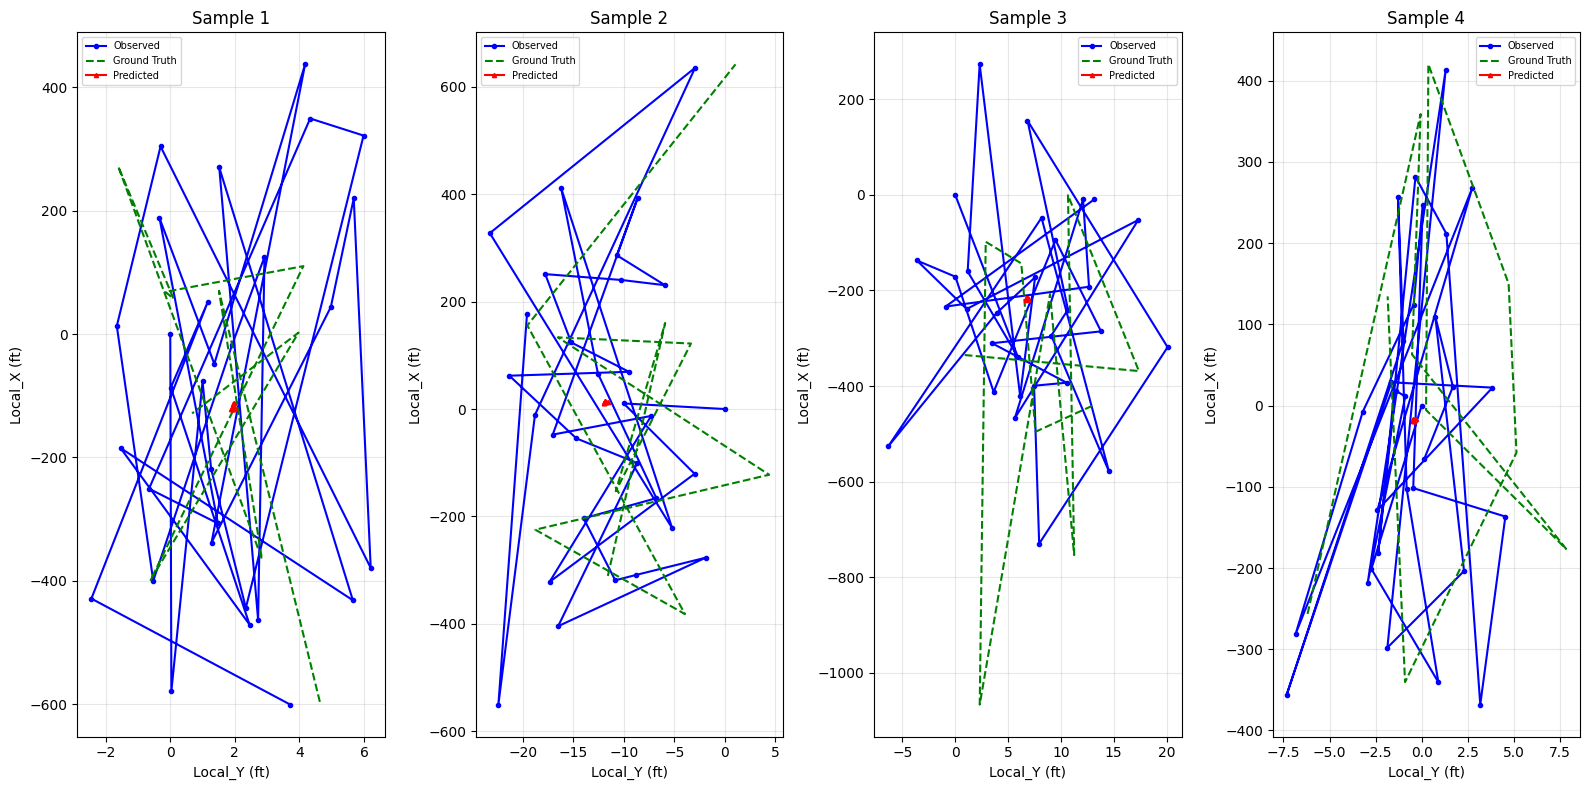

In [15]:
# get index of first sequence for each unique test vehicle
model.load_state_dict(torch.load('lstm_best.pt', map_location=device, weights_only=True))
model.eval()

seen = {}
idx = []
for i, vid in enumerate(vids_test):
    if vid not in seen:
        seen[vid] = i
        idx.append(i)
    if len(idx) == 4:
        break

fig, axes = plt.subplots(1, 4, figsize=(16, 8))
for plot_i, seq_i in enumerate(idx):
    
    xb = torch.tensor(X_test[seq_i:seq_i+1]).to(device)
    yb = Y_test[seq_i:seq_i+1]
    with torch.no_grad():
        pred_sc = model(xb).cpu().numpy()
        
    pred_rel = sy.inverse_transform(pred_sc.reshape(-1, 2)).reshape(1, PRED, 2)
    gt_rel   = sy.inverse_transform(yb.reshape(-1, 2)).reshape(1, PRED, 2)
    obs_rel  = sx.inverse_transform(X_test[seq_i:seq_i+1].reshape(-1, 2)).reshape(1, OBS, 2)
    
    ax = axes[plot_i]
    
    ax.plot(obs_rel[0, :, 0],  obs_rel[0, :, 1],  'b-o', ms=3, label='Observed')
    ax.plot(gt_rel[0,  :, 0],  gt_rel[0,  :, 1],  'g--', ms=3, label='Ground Truth')
    ax.plot(pred_rel[0, :, 0], pred_rel[0, :, 1], 'r-^', ms=3, label='Predicted')
    ax.set_title(f'Sample {plot_i+1}')
    ax.set_xlabel('Local_Y (ft)'); ax.set_ylabel('Local_X (ft)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Metrics

In [16]:
total_ade = 0.0  # Average Displacement Error
total_fde = 0.0  # Final Displacement Error  
total_rmse = 0.0 # Root Mean Square Error
num_sequences = 0

with torch.no_grad():
    for xb, yb in test_loader:
        pred_scaled = model(xb.to(device)).cpu().numpy()
        gt_scaled = yb.numpy()

        pred_ft = pred_scaled * sy.scale_ + sy.mean_
        gt_ft   = gt_scaled   * sy.scale_ + sy.mean_

        pred_m = pred_ft * 0.3048
        gt_m   = gt_ft   * 0.3048

        # Euclidean distance per timestep (meters)
        diff_m = pred_m - gt_m                     # (batch, PRED, 2)
        dist_m = np.sqrt((diff_m**2).sum(axis=-1)) # (batch, PRED)

        # ADE: average over timesteps, then sum over batch
        total_ade += dist_m.mean(axis=1).sum()

        # FDE: only the last timestep
        total_fde += dist_m[:, -1].sum()

        # RMSE: sqrt of mean of squared distances over timesteps
        #   per sequence, then sum over batch
        total_rmse += np.sqrt((diff_m**2).sum(axis=-1).mean(axis=1)).sum()

        num_sequences += len(xb)

ADE = total_ade / num_sequences
FDE = total_fde / num_sequences
RMSE = total_rmse / num_sequences

print(f"ADE: {ADE:.3f} m | FDE: {FDE:.3f} m | RMSE: {RMSE:.3f} m")

ADE: 64.587 m | FDE: 64.762 m | RMSE: 77.931 m


# Real - Time Simulation

In [ ]:

matplotlib.rcParams['animation.embed_limit'] = 35

test_vehicle_id = test_ids[0]
lane = df[df['Vehicle_ID'] == test_vehicle_id].sort_values('Frame_ID')
lane = lane[['Local_X', 'Local_Y']].values
print(f'Simulating Vehicle {test_vehicle_id} — {len(lane)} frames')


# Estimate lane boundary X positions.
x_min_road = df['Local_X'].min()
x_max_road = df['Local_X'].max()
num_lanes  = 5
lane_width = (x_max_road - x_min_road) / num_lanes
lane_boundaries = [x_min_road + i * lane_width for i in range(num_lanes + 1)]

y_start = lane[:, 1].min() - 20
y_end   = lane[:, 1].max() + 20

fig, ax = plt.subplots(figsize=(6, 10))
ax.set_xlim(x_min_road - 2, x_max_road + 2)
ax.set_ylim(y_start, y_end)
ax.set_xlabel('Local_X (ft) — lateral (across lanes, ~60 ft total)')
ax.set_ylabel('Local_Y (ft) — longitudinal (vehicle moves upward)')
ax.set_title(f'Real-Time Trajectory Prediction — Vehicle {test_vehicle_id}')
ax.grid(alpha=0.2)

# Draw vertical lane dividers
for i, bx in enumerate(lane_boundaries):
    ax.axvline(x=bx, color='black', linestyle='--', alpha=0.6, linewidth=1)
# Label lane centres
for lane_i in range(num_lanes):
    cx = lane_boundaries[lane_i] + lane_width / 2
    ax.text(cx, y_start + 10, f'Lane {lane_i+1}', ha='center',
            fontsize=8, color='black', alpha=0.7)

# Initialise plot lines
trail_line, = ax.plot([], [], color='steelblue', alpha=0.6, lw=1.2, label='Full history')
obs_line,   = ax.plot([], [], 'b-o',  ms=3, lw=1.5, label='Observed (past 3 s)')
pred_line,  = ax.plot([], [], 'r--^', ms=4, lw=1.5, label='Predicted (next 1 s)')
ax.legend(loc='upper right', fontsize=8)

model.eval()

def update(frame_idx):
    if frame_idx < OBS:
        return trail_line, obs_line, pred_line

    # Observed window
    window = lane[frame_idx - OBS : frame_idx].copy()
    origin = window[0].copy()

    # Historical trail
    history = lane[:frame_idx]
    trail_line.set_data(history[:, 0], history[:, 1])

    # Prediction
    win_rel = window - origin
    win_sc  = sx.transform(win_rel).astype(np.float32)
    inp     = torch.tensor(win_sc).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_sc = model(inp).cpu().numpy().reshape(PRED, 2)
    pred_rel = sy.inverse_transform(pred_sc)
    pred_abs = pred_rel + origin

    obs_line.set_data(window[:, 0], window[:, 1])
    pred_line.set_data(pred_abs[:, 0], pred_abs[:, 1])

    return trail_line, obs_line, pred_line

frames = range(OBS, len(lane), 5)
ani = animation.FuncAnimation(fig, update, frames=frames, interval=150, blit=True)
plt.close()
HTML(ani.to_jshtml())